In [1]:
from IPython.display import display, HTML

display(HTML("""
<style>

/* =========================
전체 레이아웃
========================= */

div.container{
    width:85% !important;
}

div.cell.code_cell.rendered{
    width:100%;
}

div.input_prompt{
    padding:0;
}

div.prompt{
    min-width:70px;
}

div#toc-wrapper{
    padding-top:120px;
}

table.dataframe{
    font-size:12px;
}

/* =========================
   코드 입력창
========================= */

div.CodeMirror{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
    line-height:1.6;
}

/* =========================
   입력 셀
========================= */

div.input{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   코드 출력
========================= */

div.output{
    font-family:"마루 부리OTF 중간" !important;
    font-size:12pt !important;
}

/* =========================
   Markdown 전체
========================= */

.rendered_html{
    font-family:"마루 부리OTF 중간" !important;
    font-size:18px !important;
    line-height:1.8;
}

/* 제목 */

.rendered_html h1,
.rendered_html h2,
.rendered_html h3,
.rendered_html h4,
.rendered_html h5,
.rendered_html h6{
    font-family:"마루 부리OTF 조금굵은" !important;
}

/* 본문 */

.rendered_html p{
    font-family:"마루 부리OTF 중간" !important;
}

/* 리스트 */

.rendered_html li{
    font-family:"마루 부리OTF 중간" !important;
    padding:5px;
}

/* 인용 */

.rendered_html blockquote{
    font-family:"마루 부리OTF 중간" !important;
}

/* 표 */

.rendered_html table{
    font-family:"마루 부리OTF 중간" !important;
}

/* 코드 블록 */

.rendered_html pre,
.rendered_html code{
    font-family:"Consolas" !important;
    font-size:12pt !important;
}

</style>
"""))

<font size="5" color="red"><b>ch3. 분류분석</b></font>
# 1절. 분류분석 개요
    - 데이터 속성을 활용하여, 데이터에 대한 분류기준을 수립하는 과정. 타겟변수가 categorical인 분석
    ex. 고객등급예측, 휴먼고객예측, 상품고매예측, 보험사기자예측...
    - sklearn 패키지
    - pip install scikit-learn

## 라이브러리의 데이터 셋의 접근
### load계열(패키지안에 데이터가 내장)
    - load_iris(), load_boston()...
    
### fetch 계열(패키지에 데이터가 없고, 인터넷 연결하여 다운로드)
    - fetch_covtype() : 토지조사 데이터
    - fetch_20newgroups() : 뉴스텍스트 말뭉치...
    
### make 계열
    - make_classification() : 분류분석용 가상의 데이터 생성
    - make_regression() : 회귀분석용 가상의 데이터 생성

In [2]:
# Load계열(패키지내에 데이터가 있음)
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
# MNIST 데이터셋 로드
(X_train, y_train), (X_test, y_test) = mnist.load_data()
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


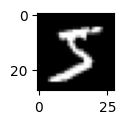

In [3]:
# 첫번째 숫자 이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X_train[0], cmap='gray')
plt.show()

In [4]:
# fetch계열(인터넷 연결후 다운로드 c:/Users/내컴퓨터명/scikit_learn_data/openml/다운)
from sklearn.datasets import fetch_openml
import numpy as np
# MNIST 다운로드
mnist = fetch_openml(name='mnist_784',
                    version=1, # 데이터버전
                    as_frame=False, # False는 넘파이배열
                    parser='auto') # 피싱 방식을 sklearn이 자동결정

In [5]:
X, y = mnist.data, mnist.target.astype(np.uint8) # y는 1byte짜리 양수int
print('원 X, y :', X.shape, y.shape)
X_reshaped = X.reshape(70000, 28,28)
print('reshape후 X, y: ', X.shape, y.shape)

원 X, y : (70000, 784) (70000,)
reshape후 X, y:  (70000, 784) (70000,)


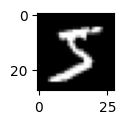

In [6]:
# 첫번째 숫자 이미지 출력
plt.figure(figsize=(1,1))
plt.imshow(X_train[0], cmap='gray')
plt.show()

# 2절. 분류분석의 종류
## 2.1 확률적 모형
- 주어진 데이터에 대해 각 클래스가 정답일 확률을 계산하는 모형
- **predict_proba() ; 각 분류 클래스가 될 확률들을 알려줌**(일부 판별함수모형에 있기는 함)
- **predict_log_proba() ; 확률의 로그값을 알려줌**
    
### 1) 확률적 생성모형
- 각 클래스별 특징 데이터의 확률분포를 추청한 다음 베이즈 정리를 사용하여 확률 계산. 소량의 데이터로도 작동하는 경우
```
    ex. sklearn.discriminant_analysis.QuadraticDiscriminantAnalysis
          sklearn.naive_bayes.MultinomialNB
```
### 2) 확률적 판별모형
- 확률 함수를 추정하는 모형. 성능이 좋고, 해석이 쉬움
```
    ex. sklearn.linear_model.LogisticeRegression
          sklearn.tree.DecisionTreeClassifier(의사결정나무) **분류에 영향을 주는 요인을 찾는데 더 많이 사용**
```

## 2.2 판별함수 모형
- 주어진 데이터를 클래스에 따라 서로 다른 영역으로 나누는 경계면을 찾은 후, 이 경계면으로부터 데이터가 어느 위치에 있는지 계산하는 판별함수를 이용하는 모형
- **decision_function() : 어떤 클래스로 분류되었는지를 알려줌**
```
    ex. sklearn.linear_model.Perceptron
          sklearn.svm.SVC
          sklearn.neural_network.MLPClassifier
```

-> RandomForest(배깅), XGboost, LGBM(부스팅), CatBoost등 앙상블 모형이 더 많이 사용됨

# 3절. 모형1 - 확률적 생성 모형
- 베이즈 정리를 사용한 확률분포 계산
## 3.1 QDA(QuadraticDiscriminantAnalysis)
- 독립변수 x가 실수이고, 정규분포라고 가정(pdf 11p)

In [7]:
# 데이터
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100, # 기본값이 100(데이터수)
                                            n_features=2, # 독립변수 개수
                                            n_informative=2, # 독립변수 중에서 종속변수에 영향을 주는 변수 개수
                                            n_redundant=0,  # 독립변수끼리 선형관계가 있는 수(제외될 변수)
                                            n_classes=2, # 클래스 수
                                            n_clusters_per_class=1, # 한 클래스당 군의 개수
                                            random_state=9,  # seed값
                                            # weights=[0.5, 0.5]
                          )
X.shape, y.shape

((100, 2), (100,))

In [8]:
# y.mean() : 0과 1 클래스가 5:5인지 확인
np.unique(y, return_counts=True)

(array([0, 1]), array([50, 50], dtype=int64))

In [9]:
# y가 0인 독립변수 X
X[y==0][:3]

array([[-0.73358502,  0.37658657],
       [-2.25158719,  3.59851363],
       [-0.6615633 ,  0.60245197]])

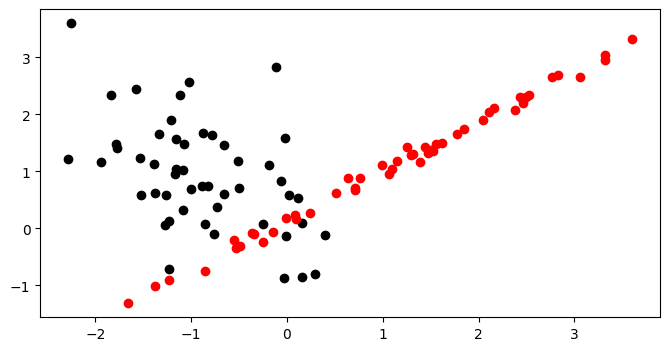

In [10]:
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 4)
# y가 0인 독립변수
plt.scatter(X[y==0, 0], X[y==0, 1], c='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='r')
plt.show()

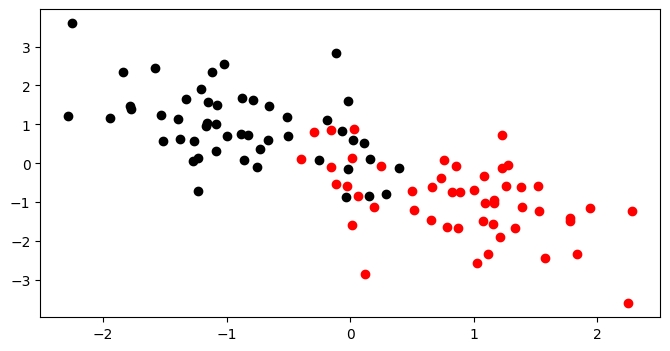

In [11]:
# 대칭구조를 만듦
X[y==1] = -X[y==0]
plt.scatter(X[y==0, 0], X[y==0, 1], c='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='r')
plt.show()

In [12]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
model = QuadraticDiscriminantAnalysis()
model.fit(X, y)

,priors,None
,reg_param,0.0
,store_covariance,False
,tol,0.0001


In [13]:
x = [[0, -1]]
p = model.predict_proba(x) # 각 class가 될 확률
print(p)

[[0.28449825 0.71550175]]


In [14]:
model.predict(x)

array([1])

In [15]:
# 모델의 분류
model.classes_

array([0, 1])

In [16]:
# 교차표(혼동행렬)
import pandas as pd
y_hat = model.predict(X)
pd.crosstab(y, y_hat, colnames=['예측'], rownames=['실제'], margins=True)

예측,0,1,All
실제,,,
0,44,6,50
1,6,44,50
All,50,50,100


In [17]:
x = [[0, -0.1]]
p = model.predict_proba(x)[0]
print(p) # 확률 2차원

[0.4769599 0.5230401]


<BarContainer object of 2 artists>

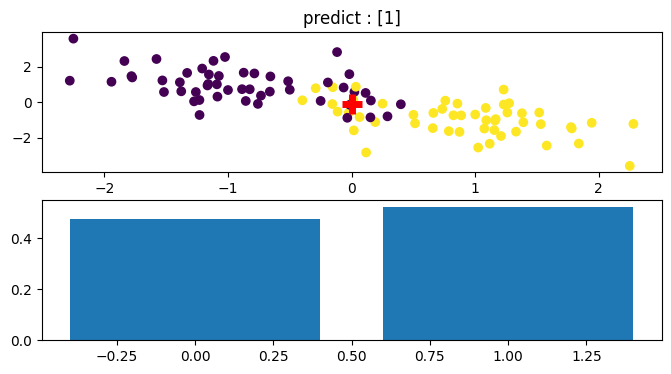

In [18]:
x = [[0, -0.1]]
p = model.predict_proba(x)[0]
plt.subplot(211) # 2행1열로 subplot에서 첫번째 그래프
plt.scatter(x=X[:, 0], y=X[:, 1], c=y)
plt.scatter(x=x[0][0], y=x[0][1], c='r', s=200, marker='+', lw=5)
h = model.predict(x)
plt.title(f'predict : {h}')

plt.subplot(212)
plt.bar(model.classes_, p)

## 3.2 나이브베이지안 모형
- MultinomialNB

In [19]:
import seaborn as sns
iris = sns.load_dataset('iris')
# 학습데이터 : 판다스 데이터 -> 넘파이배열
X = iris.iloc[:, :-1].to_numpy()
y = iris.iloc[:, -1].values
# 모형 생성 및 학습
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(X, y)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [20]:
x = [[5.1, 3.5, 1.4, 0.2]]
h = model.predict(x)
h

array(['setosa'], dtype='<U10')

In [21]:
x = [[5.0, 3.6, 1.4, 0.2]]
h = model.predict(x) # 예측값
p = model.predict_proba(x) # 각 클래스별 확률
print('예측 :', h)
print(model.classes_)
print(p)

예측 : ['setosa']
['setosa' 'versicolor' 'virginica']
[[0.75925581 0.15640083 0.08434336]]


<BarContainer object of 3 artists>

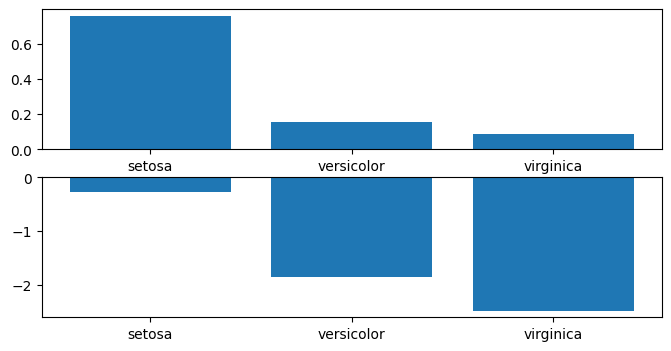

In [22]:
plt.subplot(2,1,1)
plt.bar(model.classes_, model.predict_proba(x)[0])
plt.subplot(2,1,2)
plt.bar(model.classes_, model.predict_log_proba(x)[0])

In [23]:
model.score(X, y) # 모델의 정확도

0.9533333333333334

# 4절. 모형2 - 확률적 판별모형
## 4.1 로지스틱 회귀모형
- 종속변수가 0/1

In [24]:
# 가상의 데이터 셋
X, y = make_classification(n_samples=100, # 데이터 개수(행수)
                          n_features=1, # 독립변수 개수 (기본값20)
                          n_redundant=0, # 제외될 독립변수 개수(기본값2)
                          n_informative=1, # 종속변수에 영향을 주는 독립변수 개수(기본값2)
                          n_classes=2, # 종속변수의 클래스
                          n_clusters_per_class=1, # 클래스당 군의 개수(기본값2)
                          random_state=1
                          )
X.shape, y.shape

((100, 1), (100,))

In [25]:
np.c_[X, y][:3]

array([[-1.65902848,  0.        ],
       [-0.64202884,  0.        ],
       [-1.53918976,  0.        ]])

In [26]:
np.unique(y, return_counts=True)

(array([0, 1]), array([50, 50], dtype=int64))

In [ ]:
# 모형
from sklearn.linear_model import LogisticRegression
model = LogisticRegression().fit(X, y)

In [ ]:
# 모델 예측에 쓰일 x_data (2차원)
x_data = np.linspace(-3, 3, 100) # 1차원

# 2차원 데이터를 만들기 위한 축 확장
x_data = x_data[:, np.newaxis]
# x_data = x_data.reshape(-1, 1)
# x_data = np.expand_dims(x_data, axis=1)
# x_data = x_data[:, None]
# x_data = np.array([[x] for x in x_data])
prob = model.predict_proba(x_data) # -3부터 0일 확률과 1일 확률
prob[:3]

In [ ]:
prob0 = prob[:, 0] # 0일 확률들
prob1 = prob[:, 1] # 1일 확률들

In [ ]:
plt.subplot(2, 1, 1)
plt.scatter(X, y)
plt.plot(x_data, prob0)
plt.plot(x_data, prob1, c='r')

x = [[-1]]
prob_x = model.predict_proba(x)[0]
plt.scatter(x[0], prob_x[1], marker='x', c='k', lw=5, s=100)

plt.subplot(2, 1, 2)
plt.bar(model.classes_, prob_x)
plt.show()

## 4.2 의사결정나무
- 여러가지 규칙을 순차적으로 적용하면서 독립변수 공간을 분할하는 분류모형
- **종속변수에 영향을 주는 독립변수의 범주를 찾는 목적**
- 의사결정나무 구조 시각화(base환경)

In [ ]:
from sklearn.datasets import load_iris
data = load_iris()
X = data.data[:, 2:] # petal_length, petal_width
y = data.target
feature_names = [name[:5] for name in data.feature_names[2:]]
X.shape, y.shape, feature_names

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    criterion='entropy',  # 트리의 분류 품질 기준을 entropy로
    max_depth=1,
    random_state=0
)

dt_model.fit(X, y)

In [ ]:
# 의사결정나무 분류모형의 시각화
import io
from sklearn.tree import export_graphviz # 모델 그래프 생성
# conda install graphviz
import pydot  # pip install pydot # 생성된 그래프를 이미지 변환
from IPython.core.display import Image # 이미지를 브라우저에 출력

In [ ]:
def draw_decision_tree(model, feature_names):
    dot_buf = io.StringIO()
    export_graphviz(model, out_file=dot_buf, feature_names=feature_names)
    graph = pydot.graph_from_dot_data(dot_buf.getvalue())[0]
    image = graph.create_png()
    return Image(image)

In [ ]:
draw_decision_tree(dt_model, feature_names)

In [ ]:
# 데이터 영역을 어떻게 나뉘는지 시각화
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
def plot_decision_regions(X, y, model, title):
    species = ['setosa', 'versicolor', 'virginica']
    resolution = 0.01
    markers = ('s', '^', 'o')
    colors = ('red', 'blue', 'lightgreen')
    cmap = mpl.colors.ListedColormap(colors)
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
    np.arange(x2_min, x2_max, resolution))
    Z = model.predict(
    np.array([xx1.ravel(), xx2.ravel()]).T).reshape(xx1.shape)
    plt.contour(xx1, xx2, Z, cmap=mpl.colors.ListedColormap(['k']))
    plt.contourf(xx1, xx2, Z, alpha=0.4, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], y=X[y == cl, 1], alpha=0.8,
        c=[cmap(idx)], marker=markers[idx], s=80, label=species[cl])
        plt.xlabel(data.feature_names[2])
        plt.ylabel(data.feature_names[3])
        plt.legend(loc='upper left')
        plt.title(title)
        return Z

In [ ]:
plot_decision_regions(X, y, dt_model, 'depth-1')
plt.show()

In [ ]:
x_data = [[6, 2.5]] # X[100]
dt_model.predict(x_data)

In [ ]:
print(dt_model.classes_)
print(dt_model.predict_proba(x_data))

In [ ]:
dt_model.score(X, y)

In [ ]:
dt_model5 = DecisionTreeClassifier(criterion='entropy',
                                  max_depth=5, # 최대 나무 깊이
                                  random_state=0)
dt_model5.fit(X, y)

In [ ]:
dt_model5.score(X,y)

In [ ]:
dt_model5.predict(x_data)

In [ ]:
dt_model5.predict_proba(x_data)

# 5절. 모형3 - 판별함수 모형
- 동일한 클래스가 모여 있는 영역과 그외 영역을 나누는 경계면을 정의
- decision_function()함수를 제공
- Perceptron, SVM, 다층인공신경망 모형 등이

## 5.1 Perceptron

In [ ]:
from sklearn.datasets import load_iris
import numpy as np
iris = load_iris()
X = np.r_[iris.data[:50, :2], iris.data[100:, :2]] # 0~49 + 100~149번째만
y = np.r_[iris.target[:50], iris.target[100:]]
X.shape, y.shape

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y)

In [ ]:
# 퍼셉트론 모형
from sklearn.linear_model import Perceptron
model = Perceptron(max_iter=100, # epoch
                  eta0=0.1,      # learning rate
                  random_state=1).fit(X, y)

In [ ]:
import pandas as pd
y_pred = model.predict(X)
pd.crosstab(y, y_pred, rownames=['true'], colnames=['pred'], margins=True)

In [ ]:
# 잘못 예측한 값 찾아보기
for idx, (real, pred) in enumerate(zip(y, y_pred)):
    # print(idx, real, pred)
    if real!=pred:
        print(f'{idx}번째 실제값:{real}, 예측값:{pred} - 데이터 : {X[idx]}')

In [ ]:
x_data = [[4.5, 2.3]]
print('예측 :', model.predict(x_data))
print(model.decision_function(x_data))
# decision_function(x) 결과 양수: 2
# decision_function(x) 결과 음수: 0

In [ ]:
x_data = X[0][np.newaxis, :] # X[0].reshape(1, -1), np.expand_dims(X[0], axis=0)
print('예측:', model.predict(x_data))
print(model.decision_function(x_data))

## 5.2 SVC
- Support Vector Classifier

In [ ]:
from sklearn.svm import SVC
model = SVC(
   # probability=True
)
model.fit(X, y)

In [ ]:
x_data = [[4.5, 2.3]]
print(model.predict(x_data))
print(model.decision_function(x_data)) # 음수면 0/양수면 1
#print(model.predict_proba(x_data)) # 판별함수모형

## 5.3 다중퍼셉트론(다층 인공신경망)
- predict / predict_proba / decision_function 모두 가능

In [ ]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(50, 50, 30),
                   max_iter=500) # 학습횟수가 작으면 경고가 출력되기도 함
mlp.fit(X, y)

In [ ]:
pred = mlp.predict(X)
pd.crosstab(y, pred)

# 6절. 분류모형 성능평가
## 6.1 sklearn-learn의 모형 평가 방법
- 예측 모형의 score 메서드
    *예측모형의 score(test_X, test_y)함수가 기본 제공(분류모형의 경우 accuracy, 회귀모형의 경우 r2 결정계수, 군집분석은 score없음)
- metrics 패키지 함수
    *accuracy, recall, precision, 특이도, 위양성율(fp rate), f-1score, f-beta score, ...., roc 커브,
- scoring 매개변수
    *GridSearchCV클래스를 이용한 교차검증 분석도구 => ch4.2

## 6.2 혼돈행렬을 이용한 평가
 - accuracy, recall, precision, 특이도, 위양성율(fp rate), f-1score, f-beta score

In [ ]:
import pandas as pd
result = pd.read_csv('data/model_result.csv') # 보험사기자 실제값과 예측값
result.head()

In [ ]:
result.isna().sum() # 결측치 갯수

In [ ]:
# 보험사기자 여부 0:1의 비율
print('전체 데이터수 :', result.shape[0])
print('N0:P1 빈도 :\n', result.y_true.value_counts())
print('N0:P1 비율 :\n', result.y_true.value_counts(normalize=True))

In [ ]:
# 혼돈행렬
pd.crosstab(result.y_true, result.y_pred, margins=True)

In [ ]:
# 혼돈행렬
from sklearn.metrics import confusion_matrix
confusion_matrix(result.y_true, result.y_pred)

In [ ]:
# 이진분류에서의 precision, recall
from sklearn.metrics import accuracy_score, precision_score, recall_score
print('정확도(accuracy) : ', accuracy_score(result.y_true, result.y_pred))
print('정밀도(precision) : ', precision_score(result.y_true, result.y_pred))
print('재현율(recall) : ', recall_score(result.y_true, result.y_pred))

In [ ]:
# 다중분류에서의 precisio, recall
# average : binary(기본값;이진분류), 
#           # macro(클래스별 샘플수를 가중치로 곱하여 평균계산), 
#           # weighted (클래스별 불균형이 심할 때의 평균계산)
# print('정밀도(precision) : ', precision_score(result.y_true, result.y_pred, average='macro'))
# print('재현율(recall) : ', recall_score(result.y_true, result.y_pred, average='macro'))

In [ ]:
# f1 score(precision과 recall의 조화평균) = 2 * (recall * precision) / (precision+recall)
from sklearn.metrics import f1_score, fbeta_score
print('f1 score :', f1_score(result.y_true, result.y_pred))

In [ ]:
# f beta score = (1 + beta제곱) * (recall * precision) / (beta제곱*precision + recall)
# precision의 가중치가 높음(고객의 만족도 우선) : beta가 0.5
print(fbeta_score(result.y_true, result.y_pred, beta=0.5))
# recall의 가중치가 높음(회사의 비용 중시) : beta가 2
print(fbeta_score(result.y_true, result.y_pred, beta=2))
# precision과 recall의 가중치를 같게 : beta가 1 == f1_score
print(fbeta_score(result.y_true, result.y_pred, beta=1))

In [ ]:
# 특이도 : 0이라고 제대로 예측한 수 / 실제 0인 수
spec = recall_score(result.y_true, result.y_pred, pos_label=0)

In [ ]:
# 위양성률(fp rate=1종오류, 오탐)
1 - spec

## 6.3 ROC커브를 이용한 성능 비교
- ROC커브 : 클래스의 판별 기준값의 변화에 따른 위양성률(fall-out; fp_rate)와 재현율(recall; tp_rate)의 변화를 시각화
- 세로축 : TPRate(재현율)
- 가로축 : FPRate(위양성율)

In [ ]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100,  # 데이터 행수
                           n_features=2,    # 독립변수 갯수
                           n_informative=2, # 종속변수에 영향을 주는 독립변수 갯수
                           n_redundant=0,   # 제외될 독립변수 갯수
                           n_classes=2,     # 종속변수의 class수 (0/1)
                           random_state=0)
X.shape, y.shape

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', s=50)
plt.show()

In [ ]:
from sklearn.svm import SVC
model = SVC(probability=True)
model.fit(X, y)

In [ ]:
y_pred = model.predict(X)

In [ ]:
# roc_curve()함수를 이용하여 fprate과 tprate값을 도출
    # roc_curve(y, model.decision_function(X))
    # roc_curve(y, model.predict_proba(X)[:, 1])
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y, model.decision_function(X))
# model.predict_proba(X)[:, 1] : 1로 예측될 확률
fpr1, tpr1, thresholds = roc_curve(y, model.predict_proba(X)[:, 1])
plt.figure(figsize=(3,3))
plt.plot(fpr, tpr, c='b')
plt.plot(fpr1, tpr1, c='r', alpha=0.5)
plt.xlabel('False positive Rate')
plt.ylabel('True positive Rate')
plt.show()

## 6.4 두 모형의 혼돈행렬이 같은 경우(roc_curve사용)

In [ ]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=100,
                          weights=[0.95, 0.05], # 0이 95%, 1이 5%
                          n_classes=2,
                          random_state=5)
X.shape, y.shape

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
np.unique(y, return_counts=True)

In [ ]:
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression().fit(X, y)

In [ ]:
from sklearn.svm import SVC
model2 = SVC(gamma=0.0001, # 작을수록 결정경계의 곡률이 부드러운 경계. 클수록 구불구불한 경계
            C=3000,
            probability=True).fit(X, y)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model3 = DecisionTreeClassifier(random_state=42).fit(X, y)

In [ ]:
# 세 모델의 예측값
pred1 = model1.predict(X)
pred2 = model2.predict(X)
pred3 = model3.predict(X)

In [ ]:
# 두 모델의 혼돈행렬 같음
from sklearn.metrics import confusion_matrix
confusion_matrix(y, pred1)

In [ ]:
confusion_matrix(y, pred2)

In [ ]:
# roc curve
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
fpr1, tpr1, th1 = roc_curve(y, model1.predict_proba(X)[:, 1])
fpr2, tpr2, th2 = roc_curve(y, model2.predict_proba(X)[:, 1])
plt.plot(fpr1, tpr1, c='r')
plt.plot(fpr2, tpr2, c='b')
plt.show()

In [ ]:
# AUC(Area Under Curve) : roc_curve아래면적
from sklearn.metrics import auc
auc(fpr1, tpr1), auc(fpr2, tpr2)